## Setup

In [ ]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import shapely

# import kml reading and set supported driver
import fiona
fiona.drvsupport.supported_drivers["KML"] = "rw"

# for parsing HTML inside the Description field
from bs4 import BeautifulSoup

In [ ]:
from gridsample.utils import save_shapefiles

In [ ]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"

In [ ]:
# Function to add suffix to duplicates
def add_suffix_to_duplicates(series):
    counts = {}
    result = []
    for item in series:
        if item in counts:
            counts[item] += 1
            result.append(f"{item}_S{counts[item]}")
        else:
            counts[item] = 0
            result.append(item)
    return result

## Load raw shapes and process

### Dhar

In [ ]:
# Load dhar khasras
raw_dhar_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Dhar Khasras" / "doc.kml",
    driver="KML"
)

In [ ]:
# remove z-dimension
raw_dhar_gdf.geometry = raw_dhar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons and only keep the polygon
raw_dhar_gdf = raw_dhar_gdf.explode(index_parts=False)
raw_dhar_gdf = raw_dhar_gdf[raw_dhar_gdf.geometry.type == "Polygon"]

# remove useless Description column
dhar_gdf = raw_dhar_gdf.drop(columns="Description")

In [ ]:
# drop large green shapes (open .KMZ on Google Earth to see)
dhar_gdf = dhar_gdf[dhar_gdf["Name"] != ""]

In [ ]:
# clean up Name so we can separate the villages (string names) from the areas (numbers only)
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["Name"].str.split("/")
]
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["cleaned_name"].str.split(",")
]

In [ ]:
# manual clean
dhar_gdf.loc[dhar_gdf["Name"] == "2829Z1", "cleaned_name"] = "2829"

In [ ]:
# ISOLATE AREA ONLY - select rows that have a number as their Name
dhar_yellow_shapes_gdf = dhar_gdf[dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_yellow_shapes_gdf.plot()

In [ ]:
# ISOLATE VILLAGES ONLY - select rows that have a string as their Name
dhar_village_shapes_gdf = dhar_gdf[~dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_village_shapes_gdf = dhar_village_shapes_gdf.drop(columns="cleaned_name")
dhar_village_shapes_gdf = dhar_village_shapes_gdf.rename(
    columns={"Name": "village_name"}
)
dhar_village_shapes_gdf.plot(column="village_name")

In [ ]:
# add village names to areas
dhar_processed_areas_gdf = dhar_yellow_shapes_gdf.sjoin(
    dhar_village_shapes_gdf, how="left", predicate="intersects"
).drop(columns="index_right")
dhar_processed_areas_gdf.plot(column="village_name")
print("Missing village name:", dhar_processed_areas_gdf["village_name"].isnull().sum())
print("Has village name:", dhar_processed_areas_gdf["village_name"].notnull().sum())

In [ ]:
# Apply the function to the khasra_id column
dhar_processed_areas_gdf["khasra_id"] = dhar_processed_areas_gdf["Name"]
dhar_processed_areas_gdf["khasra_id"] = add_suffix_to_duplicates(dhar_processed_areas_gdf["khasra_id"])

In [ ]:
dhar_processed_areas_gdf.drop(columns="cleaned_name", inplace=True)

In [ ]:
# save to file
save_shapefiles(
    dhar_processed_areas_gdf,
    PROCESSED_DATA_DIR,
    "dhar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Sagar

In [ ]:
gdfs = []

for filename in ["sagar_khamkuwa", "sagar_mokalpur", "sagar_tekapar"]:
    gdf = gpd.read_file(
        RAW_DATA_DIR / "solar_park_shapefiles" / "Sagar Khasras" / f"{filename}.kml",
        driver="KML",
    )
    gdf["source"] = filename
    gdfs.append(gdf)

raw_sagar_gdf = pd.concat(gdfs, ignore_index=True)

In [ ]:
# remove z-dimension
raw_sagar_gdf.geometry = raw_sagar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
raw_sagar_gdf = raw_sagar_gdf.explode(column='geometry', ignore_index=True)
raw_sagar_gdf.plot(column="source", legend=True)

In [ ]:
# Parse description variables

def description_parser(html_content):
    # Parse the HTML content
    soup = BeautifulSoup(html_content, 'html.parser')

    # Find the inner table containing the attributes
    inner_table = soup.find_all('table')[1]

    # Extract rows from the inner table
    rows = inner_table.find_all('tr')

    # Create a dictionary to store attributes and their values
    data = {}
    for row in rows:
        cols = row.find_all('td')
        if len(cols) == 2:
            key = cols[0].text.strip()
            value = cols[1].text.strip()
            data[key] = value

    return pd.DataFrame([data])

In [ ]:
# make dataframe of variables
data = [description_parser(raw_sagar_gdf["Description"].values[i]) for i in range(len(raw_sagar_gdf))]
df = pd.concat(data)
df.set_index(raw_sagar_gdf.index, inplace=True)

In [ ]:
# merge with shapes
raw_sagar_gdf.drop(columns=["Name", "Description"], inplace=True)
sagar_gdf = raw_sagar_gdf.merge(df, left_index=True, right_index=True)

In [ ]:
sagar_gdf.plot(column="PAR_TYPE")

In [ ]:
sagar_gdf["village_name"] = sagar_gdf["source"].str.split("_").str[1]
sagar_gdf["source"] = sagar_gdf["source"].str.split("_").str[0]

In [ ]:
# sagar_gdf["khasra_id"] = "SAGAR_" + sagar_gdf["UNQID"]
sagar_gdf["khasra_id"] = sagar_gdf["village_name"] + "_" + sagar_gdf["KID"]
sagar_gdf["khasra_id"] = add_suffix_to_duplicates(sagar_gdf["khasra_id"])

In [ ]:
save_shapefiles(
    sagar_gdf,
    PROCESSED_DATA_DIR,
    "sagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

## Ashok Nagar

In [185]:
gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Ashok Nagar Khasras" / "Ashok_nagar_khasras.kml",
    driver="KML",
)

In [186]:
# remove z-dimension
gdf.geometry = gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [187]:
gdf

,Name,Description,geometry
0,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71443 24.38757, 77.71444 24..."
1,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71443 24.38757, 77.71407 24..."
2,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.72160 24.38990, 77.72142 24..."
3,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71978 24.38991, 77.71959 24..."
4,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71797 24.38994, 77.71754 24..."
...,...,...,...
342,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85647 24.70911, 77.85646 24..."
343,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85645 24.70830, 77.85648 24..."
344,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85743 24.70827, 77.85696 24..."
345,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85831 24.70821, 77.85815 24..."


<Axes: >

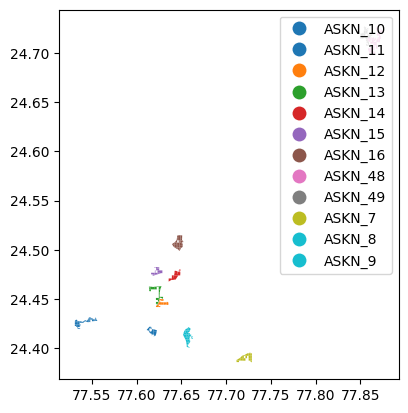

In [188]:
gdf.plot(column="Name", legend=True)

In [189]:
data = [description_parser(gdf["Description"].values[i]) for i in range(len(gdf))]
df = pd.concat(data)
df.set_index(gdf.index, inplace=True)

In [190]:
# merge with shapes
gdf.drop(columns=["Name", "Description"], inplace=True)
gdf_merged = gdf.merge(df, left_index=True, right_index=True)

In [191]:
gdf_merged.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
        "khasra_no": "Name",
        "Patch_Name": "parcel_id",
    },
    inplace=True,
)

In [192]:
save_shapefiles(
    gdf_merged,
    PROCESSED_DATA_DIR,
    "ashok_nagar_cleaned_khasras",
    formats=["kml", "parquet"],
)